<div style="width: 76ch;">
<h3>Ruitenwissers-mechanisme</h3>
(<em>Colin Cools, Lander Cortens</em>)

<div style="height: 20rem;">
 <img style="border: 0; display: inline-block;" height="100%"
      src="images/ruitenwissers_foto.png"
 >
</div>

</div>

## Inhoudsopgave

- [Mobiliteit van het mechanisme](#mobiliteit)
- [1. Imports en instellingen](#sectie-1)
- [2. Geometrie en simulatie-instellingen](#sectie-2)
- [3. Hulpfuncties en sluitingsvergelijkingen](#sectie-3)
- [4. Beginstand](#sectie-4)
- [5. Controleplot van de beginstand](#sectie-5)
- [6. Kinematicafuncties](#sectie-6)
- [7. Kinematica over een volledige cyclus](#sectie-7)
- [8. Kinematische grafieken](#sectie-8)
- [9. Transmissiehoeken](#sectie-9)
- [10. Animatie van het mechanisme](#sectie-10)
- [11. Massa, inertie, zwaartekracht en wrijving](#sectie-11)
- [12. Inverse dynamica](#sectie-12)
- [13. Scharnierkrachten en aandrijfmoment](#sectie-13)
- [14. Onbalanskrachten](#sectie-14)
- [15. Controle van de onbalanskrachten](#sectie-15)
- [16. Energiecontrole](#sectie-16)
- [17. Motoranalyse](#sectie-17)
- [18. Motorkeuze en gebruikskost](#sectie-18)
- [19. Vliegwielanalyse](#sectie-19)
- [20. Besluit over het vliegwiel](#sectie-20)
- [21. Examen-checklist](#sectie-21)


<a id="mobiliteit"></a>
## Mobiliteit van het mechanisme

Zoals in Les1B gebruiken we voor een vlak mechanisme de Chebychev-Grübler-Kutzbach-formule:

$$M = 3(n-1) - 2 f_1 - f_2$$

Daarbij is $n$ het aantal gelederen, inclusief de grond. $f_1$ is het aantal gewrichten met 1 vrijheidsgraad, dus hier de rotatiegewrichten. $f_2$ is het aantal gewrichten met 2 vrijheidsgraden; die hebben we in dit stangenmechanisme niet.

Voor ons ruitenwissermechanisme:

| Grootheid | Betekenis | Waarde |
|---|---|---:|
| $n$ | grond + bewegende links 1 t/m 7 | 8 |
| $f_1$ | rotatiegewrichten A, B, C, D, E, F, G, H, I en J | 10 |
| $f_2$ | hogere paren, zoals nok/rolcontact | 0 |

Dus:

$$M = 3(8-1) - 2\cdot 10 - 0 = 21 - 20 = 1$$

Het mechanisme heeft dus **mobiliteit 1**. Dat betekent dat één onafhankelijke input voldoende is om de volledige configuratie vast te leggen. In deze notebook is dat de motorhoek `theta1` rond grondpunt A; alle andere hoeken (`theta2` t/m `theta7`) volgen uit de sluitingsvergelijkingen.

Dit klopt ook met de code: er zijn zes onbekende hoeken en zes sluitingsvergelijkingen (`F1` t/m `F6`). Zodra `theta1` opgelegd wordt, is de rest van de configuratie bepaald, behalve bij een singulariteit of als `fsolve` op een andere configuratietak terechtkomt.


<a id="sectie-1"></a>
## 1. Imports en instellingen



In [1]:
# Animation of four bar


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams.update({
    "figure.dpi": 70,
    "savefig.dpi": 70,
})

%matplotlib widget

<a id="sectie-2"></a>
## 2. Geometrie en simulatie-instellingen

Lengtes, vaste draaipunten, motorsnelheid en tijdstap voor een volledige cyclus.


In [2]:
# Link lengths [m]
r1 = 0.11
r2 = 0.99 #0.95 voor oplijning 2 en 3 of 1.01 voor oplijning ruitenwissers zelf
r3 = 1.53
r4 = 1.01
r5 = 1.13
r6 = 0.90
r7 = 0.5

# Distances from the ternary links to their joints [m]
rDC = 0.16
rDF = 0.41
rED = 0.28
rIJ = 0.28

# Fixed ground points [m]
grondA_x = 0.00
grondA_y = 0.00

grondD_x = 0.76
grondD_y = 0.66

grondH_x = 1.79
grondH_y = 0.01

grondI_x = 1.77
grondI_y = 0.66

# Derived distances between ground points [m]
rAD_x = abs(grondD_x - grondA_x)
rAD_y = abs(grondD_y - grondA_y)

rAH_x = abs(grondH_x - grondA_x)
rAH_y = abs(grondH_y - grondA_y)

rAI_x = abs(grondI_x - grondA_x)
rAI_y = abs(grondI_y - grondA_y)

rDH_x = abs(grondH_x - grondD_x)
rDH_y = abs(grondH_y - grondD_y)

rDI_x = abs(grondD_x - grondI_x)
rDI_y = abs(grondD_y - grondI_y)

# Prescribed input motion
omega = 4.2       # [rad/s], driver angular speed = 40 rpm
t_begin = 0       # [s], start time of simulation
t_end = 2*np.pi/omega  # [s], one full driver revolution
Ts = 0.05         # [s], target time step of simulation
num_steps = int(np.ceil((t_end - t_begin) / Ts))
t = np.linspace(t_begin, t_end, num_steps + 1)  # [s], time vector

theta1_0 = np.deg2rad(65)       # [rad], initial driver angle
theta1 = theta1_0 + omega * t   # [rad]
dtheta1 = omega * np.ones_like(t)       # [rad/s]
ddtheta1 = np.zeros_like(t)             # [rad/s^2]

# Initial guesses for the nonlinear position closure.
# phi1_init = 1.22 #rad volgens mij is deze bepaald door de motor, dus mag deze weg
theta2_init = np.deg2rad(15)
theta3_init = np.deg2rad(115)
theta4_init = np.deg2rad(-20)   # stang 6
theta5_init = np.deg2rad(50)    # stang 7
theta6_init = np.deg2rad(0)     # stang 4
theta7_init = np.deg2rad(120)   # stang 5
# (different choices can lead to different topologies of your mechanism)


<a id="sectie-3"></a>
## 3. Hulpfuncties en sluitingsvergelijkingen

Functies voor vectorrotatie en positiessluiting van het mechanisme.


In [3]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, z)

In [4]:
# Define function to compute "gap" in position closure:
def loop_closure_eqs(theta_init, theta1, r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y):
    theta2 = theta_init[0]
    theta3 = theta_init[1]
    theta4 = theta_init[2]
    theta5 = theta_init[3]
    theta6 = theta_init[4]
    theta7 = theta_init[5]
    

    # Loop closure gaps:
    F1 = r1 * np.cos(theta1) + r2 * np.cos(theta2) + rDC * np.cos(theta3) - rAD_x
    F2 = r1 * np.sin(theta1) + r2 * np.sin(theta2) + rDC * np.sin(theta3) - rAD_y

    F3 = -rDF * np.cos(theta3) + r6 * np.cos(theta4) - r7 * np.cos(theta5) - rDH_x
    F4 = -rDF * np.sin(theta3) + r6 * np.sin(theta4) - r7 * np.sin(theta5) + rDH_y

    F5 = rED * np.cos(theta3) + r4 * np.cos(theta6) - rIJ * np.cos(theta7) - rDI_x
    F6 = rED * np.sin(theta3) + r4 * np.sin(theta6) - rIJ * np.sin(theta7) - rDI_y

    return [F1, F2, F3, F4, F5, F6]

<a id="sectie-4"></a>
## 4. Beginstand

Numerieke oplossing van de onbekende hoeken op tijdstip nul.


In [5]:
# calculating unknown angles at time zero
def angles_at_time_zero(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t):
    optim_options = {"full_output":True}  # options for fsolve

  # numerically solving the position closure at all sampling times:
    #for k, time in enumerate(t):
    #for k, time in [0]:
    k=0
    if k ==0:
      # Position Analysis
      x, _, ier, message  = fsolve(lambda x: loop_closure_eqs(x, theta1[k], r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y), [theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init], **optim_options)

      if ier != 1:
          print("The fsolve exit flag was not 1, probably no convergence!")
          print(message)

      theta2 = x[0]
      theta3 = x[1]
      theta4 = x[2]
      theta5 = x[3]
      theta6 = x[4]
      theta7 = x[5]

      

    return theta2, theta3, theta4, theta5, theta6, theta7

theta2_0, theta3_0, theta4_0, theta5_0, theta6_0, theta7_0 = angles_at_time_zero(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t)

<a id="sectie-5"></a>
## 5. Controleplot van de beginstand


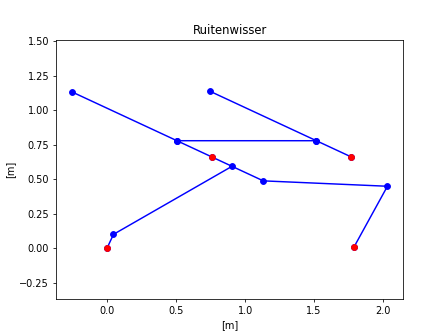

In [6]:
# making plot at time zero
A = np.array([0, 0])
B = A + rotate_vector(np.array([r1, 0]), theta1[0])
C = B + rotate_vector(np.array([r2, 0]), theta2_0)
D = A + np.array([rAD_x, rAD_y])
I = A + np.array([rAI_x, rAI_y])
H = A + np.array([rAH_x, rAH_y])
G = H + rotate_vector(np.array([r7, 0]), theta5_0)
F = G - rotate_vector(np.array([r6, 0]), theta4_0)
K = F + rotate_vector(np.array([r3, 0]), theta3_0)
E = F + rotate_vector(np.array([rED + rDF, 0]), theta3_0)
J = I + rotate_vector(np.array([rIJ, 0]), theta7_0)
L = I + rotate_vector(np.array([r5, 0]), theta7_0)



plt.figure()
pad1 = np.array([H, G, F, D, E, J, I])
plt.plot(pad1[:, 0], pad1[:, 1], '-bo')
pad2 = np.array([A, B,C])
plt.plot(pad2[:, 0], pad2[:, 1], '-bo')
pad3 = np.array([E,K])
plt.plot(pad3[:, 0], pad3[:, 1], '-bo')
pad4 = np.array([J,L])
plt.plot(pad4[:, 0], pad4[:, 1], '-bo')

plt.plot(A[0], A[1], 'ro')  # vaste pivot
plt.plot(D[0], D[1], 'ro')
plt.plot(H[0], H[1], 'ro')
plt.plot(I[0], I[1], 'ro')
plt.xlabel('[m]')
plt.ylabel('[m]')
plt.title('Ruitenwisser')
plt.axis('equal')
plt.show()




<a id="sectie-6"></a>
## 6. Kinematicafuncties

Berekening van posities, hoeksnelheden, hoekversnellingen en massacentrumkinematica.


In [7]:
# Function to compute the kinematics
def kinematics(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t):
    optim_options = {"full_output":True}  # options for fsolve

  # numerically solving the position closure at all sampling times:
    for k, time in enumerate(t):
      # Position Analysis
      x, _, ier, message  = fsolve(lambda x: loop_closure_eqs(x, theta1[k], r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y), [theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init], **optim_options)

      if ier != 1:
          print("The fsolve exit flag was not 1, probably no convergence!")
          print(message)

      theta2[k] = x[0]
      theta3[k] = x[1]
      theta4[k] = x[2]
      theta5[k] = x[3]
      theta6[k] = x[4]
      theta7[k] = x[5]

      # velocity closure:
      A = np.array([
        [-r2*np.sin(theta2[k]), -rDC*np.sin(theta3[k]), 0, 0, 0, 0],
        [ r2*np.cos(theta2[k]),  rDC*np.cos(theta3[k]), 0, 0, 0, 0],
        [0,  rDF*np.sin(theta3[k]), -r6*np.sin(theta4[k]),  r7*np.sin(theta5[k]), 0, 0],
        [0, -rDF*np.cos(theta3[k]),  r6*np.cos(theta4[k]), -r7*np.cos(theta5[k]), 0, 0],
        [0, -rED*np.sin(theta3[k]), 0, 0, -r4*np.sin(theta6[k]),  rIJ*np.sin(theta7[k])],
        [0,  rED*np.cos(theta3[k]), 0, 0,  r4*np.cos(theta6[k]), -rIJ*np.cos(theta7[k])]
      ])

      B = np.array([
        r1*np.sin(theta1[k])*dtheta1[k],
        -r1*np.cos(theta1[k])*dtheta1[k],
        0,
        0,
        0,
        0
      ])

      x = np.linalg.solve(A, B)
      cond[k]  = np.linalg.cond(A)

      dtheta2[k] = x[0]
      dtheta3[k] = x[1]
      dtheta4[k] = x[2]
      dtheta5[k] = x[3]
      dtheta6[k] = x[4]
      dtheta7[k] = x[5]

      A = np.array([
        [-r2*np.sin(theta2[k]), -rDC*np.sin(theta3[k]), 0, 0, 0, 0],
        [ r2*np.cos(theta2[k]),  rDC*np.cos(theta3[k]), 0, 0, 0, 0],
        [0,  rDF*np.sin(theta3[k]), -r6*np.sin(theta4[k]),  r7*np.sin(theta5[k]), 0, 0],
        [0, -rDF*np.cos(theta3[k]),  r6*np.cos(theta4[k]), -r7*np.cos(theta5[k]), 0, 0],
        [0, -rED*np.sin(theta3[k]), 0, 0, -r4*np.sin(theta6[k]),  rIJ*np.sin(theta7[k])],
        [0,  rED*np.cos(theta3[k]), 0, 0,  r4*np.cos(theta6[k]), -rIJ*np.cos(theta7[k])]
      ])

      B = np.array([
        r1*np.cos(theta1[k])*dtheta1[k]**2 + r1*np.sin(theta1[k])*ddtheta1[k]
        + r2*np.cos(theta2[k])*dtheta2[k]**2 + rDC*np.cos(theta3[k])*dtheta3[k]**2,

        r1*np.sin(theta1[k])*dtheta1[k]**2 - r1*np.cos(theta1[k])*ddtheta1[k]
        + r2*np.sin(theta2[k])*dtheta2[k]**2 + rDC*np.sin(theta3[k])*dtheta3[k]**2,

        -rDF*np.cos(theta3[k])*dtheta3[k]**2 + r6*np.cos(theta4[k])*dtheta4[k]**2 - r7*np.cos(theta5[k])*dtheta5[k]**2,

        -rDF*np.sin(theta3[k])*dtheta3[k]**2 + r6*np.sin(theta4[k])*dtheta4[k]**2 - r7*np.sin(theta5[k])*dtheta5[k]**2,

        rED*np.cos(theta3[k])*dtheta3[k]**2 + r4*np.cos(theta6[k])*dtheta6[k]**2 - rIJ*np.cos(theta7[k])*dtheta7[k]**2,

        rED*np.sin(theta3[k])*dtheta3[k]**2 + r4*np.sin(theta6[k])*dtheta6[k]**2 - rIJ*np.sin(theta7[k])*dtheta7[k]**2
      ])

      x = np.linalg.solve(A, B)
      
      ddtheta2[k] = x[0]
      ddtheta3[k] = x[1]
      ddtheta4[k] = x[2]
      ddtheta5[k] = x[3]
      ddtheta6[k] = x[4]
      ddtheta7[k] = x[5] 

      theta2_init = theta2[k] + (t[1] - t[0])*dtheta2[k]
      theta3_init = theta3[k] + (t[1] - t[0])*dtheta3[k]
      theta4_init = theta4[k] + (t[1] - t[0])*dtheta4[k]
      theta5_init = theta5[k] + (t[1] - t[0])*dtheta5[k]
      theta6_init = theta6[k] + (t[1] - t[0])*dtheta6[k]
      theta7_init = theta7[k] + (t[1] - t[0])*dtheta7[k]

    return theta2, theta3, theta4, theta5, theta6, theta7, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7, cond

def center_of_mass_kinematics(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                              dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                              ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
                              r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
                              X1, X2, X3, X4, X5, X6, X7,
                              Y1, Y2, Y3, Y4, Y5, Y6, Y7):
    # link numbering follows the sketch:
    # link 4 uses theta6, link 5 uses theta7, link 6 uses theta4 and link 7 uses theta5
    cog1_A_x = -X1 * np.cos(theta1) - Y1 * np.cos(theta1 + np.pi / 2)
    cog1_A_y = -X1 * np.sin(theta1) - Y1 * np.sin(theta1 + np.pi / 2)
    cog2_B_x = -X2 * np.cos(theta2) - Y2 * np.cos(theta2 + np.pi / 2)
    cog2_B_y = -X2 * np.sin(theta2) - Y2 * np.sin(theta2 + np.pi / 2)
    cog3_D_x = -X3 * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_D_y = -X3 * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)
    cog4_E_x = -X4 * np.cos(theta6) - Y4 * np.cos(theta6 + np.pi / 2)
    cog4_E_y = -X4 * np.sin(theta6) - Y4 * np.sin(theta6 + np.pi / 2)
    cog5_I_x = -X5 * np.cos(theta7) - Y5 * np.cos(theta7 + np.pi / 2)
    cog5_I_y = -X5 * np.sin(theta7) - Y5 * np.sin(theta7 + np.pi / 2)
    cog6_F_x = -X6 * np.cos(theta4) - Y6 * np.cos(theta4 + np.pi / 2)
    cog6_F_y = -X6 * np.sin(theta4) - Y6 * np.sin(theta4 + np.pi / 2)
    cog7_H_x = -X7 * np.cos(theta5) - Y7 * np.cos(theta5 + np.pi / 2)
    cog7_H_y = -X7 * np.sin(theta5) - Y7 * np.sin(theta5 + np.pi / 2)

    omega1 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta1))
    omega2 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta2))
    omega3 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta3))
    omega4 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta6))
    omega5 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta7))
    omega6 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta4))
    omega7 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta5))

    alpha1 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta1))
    alpha2 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta2))
    alpha3 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta3))
    alpha4 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta6))
    alpha5 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta7))
    alpha6 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta4))
    alpha7 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta5))

    A_cog1_vec = np.column_stack((-cog1_A_x, -cog1_A_y, np.zeros_like(theta1)))
    B_cog2_vec = np.column_stack((-cog2_B_x, -cog2_B_y, np.zeros_like(theta1)))
    D_cog3_vec = np.column_stack((-cog3_D_x, -cog3_D_y, np.zeros_like(theta1)))
    E_cog4_vec = np.column_stack((-cog4_E_x, -cog4_E_y, np.zeros_like(theta1)))
    I_cog5_vec = np.column_stack((-cog5_I_x, -cog5_I_y, np.zeros_like(theta1)))
    F_cog6_vec = np.column_stack((-cog6_F_x, -cog6_F_y, np.zeros_like(theta1)))
    H_cog7_vec = np.column_stack((-cog7_H_x, -cog7_H_y, np.zeros_like(theta1)))

    AB_vec = np.column_stack((r1 * np.cos(theta1), r1 * np.sin(theta1), np.zeros_like(theta1)))
    DE_vec = np.column_stack((rED * np.cos(theta3), rED * np.sin(theta3), np.zeros_like(theta1)))
    DF_vec = np.column_stack((-rDF * np.cos(theta3), -rDF * np.sin(theta3), np.zeros_like(theta1)))

    vel_1 = np.cross(omega1, A_cog1_vec)
    vel_B = np.cross(omega1, AB_vec)
    vel_2 = vel_B + np.cross(omega2, B_cog2_vec)
    vel_3 = np.cross(omega3, D_cog3_vec)
    vel_E = np.cross(omega3, DE_vec)
    vel_F = np.cross(omega3, DF_vec)
    vel_4 = vel_E + np.cross(omega4, E_cog4_vec)
    vel_5 = np.cross(omega5, I_cog5_vec)
    vel_6 = vel_F + np.cross(omega6, F_cog6_vec)
    vel_7 = np.cross(omega7, H_cog7_vec)

    acc_1 = np.cross(omega1, np.cross(omega1, A_cog1_vec)) + np.cross(alpha1, A_cog1_vec)
    acc_B = np.cross(omega1, np.cross(omega1, AB_vec)) + np.cross(alpha1, AB_vec)
    acc_2 = acc_B + np.cross(omega2, np.cross(omega2, B_cog2_vec)) + np.cross(alpha2, B_cog2_vec)
    acc_3 = np.cross(omega3, np.cross(omega3, D_cog3_vec)) + np.cross(alpha3, D_cog3_vec)
    acc_E = np.cross(omega3, np.cross(omega3, DE_vec)) + np.cross(alpha3, DE_vec)
    acc_F = np.cross(omega3, np.cross(omega3, DF_vec)) + np.cross(alpha3, DF_vec)
    acc_4 = acc_E + np.cross(omega4, np.cross(omega4, E_cog4_vec)) + np.cross(alpha4, E_cog4_vec)
    acc_5 = np.cross(omega5, np.cross(omega5, I_cog5_vec)) + np.cross(alpha5, I_cog5_vec)
    acc_6 = acc_F + np.cross(omega6, np.cross(omega6, F_cog6_vec)) + np.cross(alpha6, F_cog6_vec)
    acc_7 = np.cross(omega7, np.cross(omega7, H_cog7_vec)) + np.cross(alpha7, H_cog7_vec)

    speeds = [np.linalg.norm(vel, axis=1) for vel in (vel_1, vel_2, vel_3, vel_4, vel_5, vel_6, vel_7)]

    return (
        vel_1[:, 0], vel_1[:, 1], vel_2[:, 0], vel_2[:, 1], vel_3[:, 0], vel_3[:, 1],
        vel_4[:, 0], vel_4[:, 1], vel_5[:, 0], vel_5[:, 1], vel_6[:, 0], vel_6[:, 1],
        vel_7[:, 0], vel_7[:, 1], *speeds,
        acc_1[:, 0], acc_1[:, 1], acc_2[:, 0], acc_2[:, 1], acc_3[:, 0], acc_3[:, 1],
        acc_4[:, 0], acc_4[:, 1], acc_5[:, 0], acc_5[:, 1], acc_6[:, 0], acc_6[:, 1],
        acc_7[:, 0], acc_7[:, 1]
    )


def center_of_mass_positions(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                             r1, rED, rDF,
                             grondA_x, grondA_y, grondD_x, grondD_y,
                             grondH_x, grondH_y, grondI_x, grondI_y,
                             X1, X2, X3, X4, X5, X6, X7,
                             Y1, Y2, Y3, Y4, Y5, Y6, Y7):
    cog_1_x = grondA_x + X1 * np.cos(theta1) + Y1 * np.cos(theta1 + np.pi / 2)
    cog_1_y = grondA_y + X1 * np.sin(theta1) + Y1 * np.sin(theta1 + np.pi / 2)

    point_B_x = grondA_x + r1 * np.cos(theta1)
    point_B_y = grondA_y + r1 * np.sin(theta1)
    cog_2_x = point_B_x + X2 * np.cos(theta2) + Y2 * np.cos(theta2 + np.pi / 2)
    cog_2_y = point_B_y + X2 * np.sin(theta2) + Y2 * np.sin(theta2 + np.pi / 2)

    cog_3_x = grondD_x + X3 * np.cos(theta3) + Y3 * np.cos(theta3 + np.pi / 2)
    cog_3_y = grondD_y + X3 * np.sin(theta3) + Y3 * np.sin(theta3 + np.pi / 2)

    point_E_x = grondD_x + rED * np.cos(theta3)
    point_E_y = grondD_y + rED * np.sin(theta3)
    cog_4_x = point_E_x + X4 * np.cos(theta6) + Y4 * np.cos(theta6 + np.pi / 2)
    cog_4_y = point_E_y + X4 * np.sin(theta6) + Y4 * np.sin(theta6 + np.pi / 2)

    cog_5_x = grondI_x + X5 * np.cos(theta7) + Y5 * np.cos(theta7 + np.pi / 2)
    cog_5_y = grondI_y + X5 * np.sin(theta7) + Y5 * np.sin(theta7 + np.pi / 2)

    point_F_x = grondD_x - rDF * np.cos(theta3)
    point_F_y = grondD_y - rDF * np.sin(theta3)
    cog_6_x = point_F_x + X6 * np.cos(theta4) + Y6 * np.cos(theta4 + np.pi / 2)
    cog_6_y = point_F_y + X6 * np.sin(theta4) + Y6 * np.sin(theta4 + np.pi / 2)

    cog_7_x = grondH_x + X7 * np.cos(theta5) + Y7 * np.cos(theta5 + np.pi / 2)
    cog_7_y = grondH_y + X7 * np.sin(theta5) + Y7 * np.sin(theta5 + np.pi / 2)

    return (
        cog_1_x, cog_1_y, cog_2_x, cog_2_y, cog_3_x, cog_3_y,
        cog_4_x, cog_4_y, cog_5_x, cog_5_y, cog_6_x, cog_6_y,
        cog_7_x, cog_7_y
    )

<a id="sectie-7"></a>
## 7. Kinematica over een volledige cyclus


In [8]:
theta2   = np.zeros_like(t)
theta3   = np.zeros_like(t)
theta4   = np.zeros_like(t)
theta5   = np.zeros_like(t)
theta6   = np.zeros_like(t)
theta7   = np.zeros_like(t)

dtheta2   = np.zeros_like(t)
dtheta3   = np.zeros_like(t)
dtheta4   = np.zeros_like(t)
dtheta5   = np.zeros_like(t)
dtheta6   = np.zeros_like(t)
dtheta7   = np.zeros_like(t)

ddtheta2   = np.zeros_like(t)
ddtheta3   = np.zeros_like(t)
ddtheta4   = np.zeros_like(t)
ddtheta5   = np.zeros_like(t)
ddtheta6   = np.zeros_like(t)
ddtheta7   = np.zeros_like(t)

cond   = np.zeros_like(t) # condition number of matrix A

t_size = len(t)              # number of iterations
sim_fraction = 2             # fraction of simulated frames in animation
frames = int(t_size / sim_fraction)# number of animated iterations
delta = int(np.floor(t_size/frames))    # time between frames
index_vec = np.arange(0, t_size, delta) # index of animated frames  

theta2, theta3, theta4, theta5, theta6, theta7, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7, cond = kinematics(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t)

<a id="sectie-8"></a>
## 8. Kinematische grafieken


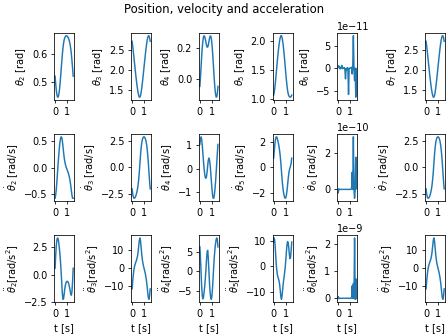

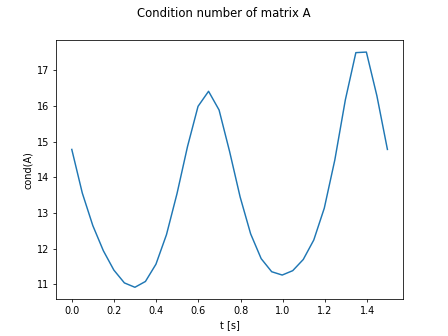

In [9]:
# plot position, velocity and acceleration profiles:

fig1, ax1 = plt.subplots(nrows=3,ncols=6,constrained_layout=True)
fig1.suptitle("Position, velocity and acceleration")

ax1[0,0].plot(t, theta2)
ax1[0,0].set_ylabel(r'$\theta_2$ [rad]')

ax1[0,1].plot(t, theta3)
ax1[0,1].set_ylabel(r'$\theta_3$ [rad]')

ax1[0,2].plot(t, theta4)
ax1[0,2].set_ylabel(r'$\theta_4$ [rad]')

ax1[0,3].plot(t, theta5)
ax1[0,3].set_ylabel(r'$\theta_5$ [rad]')

ax1[0,4].plot(t, theta6)
ax1[0,4].set_ylabel(r'$\theta_6$ [rad]')

ax1[0,5].plot(t, theta7)
ax1[0,5].set_ylabel(r'$\theta_7$ [rad]')

ax1[1,0].plot(t, dtheta2)
ax1[1,0].set_ylabel(r'$\dot{\theta}_2$ [rad/s]')

ax1[1,1].plot(t, dtheta3)
ax1[1,1].set_ylabel(r'$\dot{\theta}_3$ [rad/s]')

ax1[1,2].plot(t, dtheta4)
ax1[1,2].set_ylabel(r'$\dot{\theta}_4$ [rad/s]')

ax1[1,3].plot(t, dtheta5)
ax1[1,3].set_ylabel(r'$\dot{\theta}_5$ [rad/s]')

ax1[1,4].plot(t, dtheta6)
ax1[1,4].set_ylabel(r'$\dot{\theta}_6$ [rad/s]')

ax1[1,5].plot(t, dtheta7)
ax1[1,5].set_ylabel(r'$\dot{\theta}_7$ [rad/s]')

ax1[2,0].plot(t, ddtheta2)
ax1[2,0].set_ylabel(r'$\ddot{\theta}_2 [\text{rad/s}^2]$')
ax1[2,0].set_xlabel('t [s]')

ax1[2,1].plot(t, ddtheta3)
ax1[2,1].set_ylabel(r'$\ddot{\theta}_3 [\text{rad/s}^2]$')
ax1[2,1].set_xlabel('t [s]')

ax1[2,2].plot(t, ddtheta4)
ax1[2,2].set_ylabel(r'$\ddot{\theta}_4 [\text{rad/s}^2]$')
ax1[2,2].set_xlabel('t [s]')

ax1[2,3].plot(t, ddtheta5)
ax1[2,3].set_ylabel(r'$\ddot{\theta}_5 [\text{rad/s}^2]$')
ax1[2,3].set_xlabel('t [s]')

ax1[2,4].plot(t, ddtheta6)
ax1[2,4].set_ylabel(r'$\ddot{\theta}_6 [\text{rad/s}^2]$')
ax1[2,4].set_xlabel('t [s]')

ax1[2,5].plot(t, ddtheta7)
ax1[2,5].set_ylabel(r'$\ddot{\theta}_7 [\text{rad/s}^2]$')
ax1[2,5].set_xlabel('t [s]')

plt.show()

# plot of condition number:
figc, axc = plt.subplots()
figc.suptitle("Condition number of matrix A")

axc.plot(t, cond)
axc.set_ylabel("cond(A)")
axc.set_xlabel('t [s]')
plt.show()

<a id="sectie-9"></a>
## 9. Transmissiehoeken

Zoals in Les2 wordt de overbrengingshoek of transmissiehoek gebruikt als maat voor de efficiëntie waarmee een kracht of koppel door een stangenlus wordt doorgegeven. Een transmissiehoek dicht bij $90^\circ$ is gunstig. Wanneer de transmissiehoek dicht bij $0^\circ$ of $180^\circ$ komt, liggen twee stangen bijna in elkaars verlengde en komt het mechanisme dicht bij een dode stand of singulariteit.

Dit mechanisme bestaat niet uit één eenvoudige vierstang, maar uit drie gekoppelde lussen. Daarom worden drie lokale transmissiehoeken bekeken:

| Lus | Betrokken stangen | Transmissiehoek |
|---|---|---|
| A-B-C-D | `r2` en `rDC` | $\gamma_{BCD}$ |
| D-F-G-H | `r6` en `r7` | $\gamma_{FGH}$ |
| D-E-J-I | `r4` en `rIJ` | $\gamma_{EJI}$ |

De effectieve transmissiehoek wordt hier telkens tussen $0^\circ$ en $90^\circ$ gezet. Een kleine waarde betekent dus een slechte krachtoverbrenging. Vooral de lus D-E-J-I is belangrijk, omdat die ook in de singulariteitsanalyse het dichtst bij een uitgestrekte toggle-stand komt.


Minimum effective transmission angles
A-B-C-D: r2 vs rDC      :  40.46 deg at theta1 = 221.00 deg
D-F-G-H: r6 vs r7       :  63.10 deg at theta1 =  77.00 deg
D-E-J-I: r4 vs rIJ      :  17.13 deg at theta1 =  29.00 deg


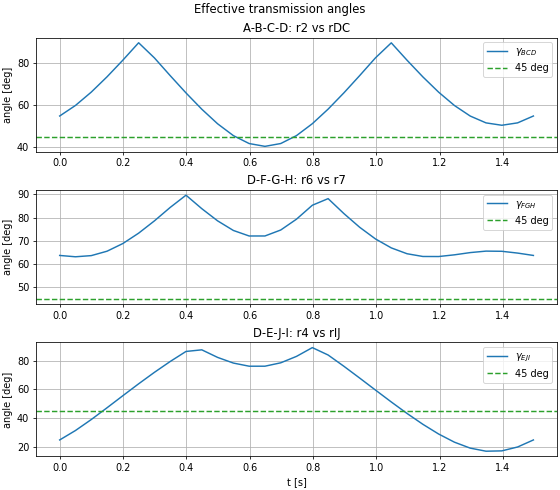

In [10]:
# Transmission angles for the three coupled loops.
# The effective transmission angle is folded to [0, 90] degrees:
# 90 deg = favourable force transmission, 0 deg = near toggle/dead-point.

def effective_transmission_angle(theta_a, theta_b):
    gamma = np.abs(theta_a - theta_b)
    gamma = np.mod(gamma, 2*np.pi)
    gamma = np.minimum(gamma, 2*np.pi - gamma)   # [0, pi]
    gamma_eff = np.minimum(gamma, np.pi - gamma) # [0, pi/2]
    return gamma_eff

gamma_BCD = effective_transmission_angle(theta2, theta3) # between r2 and rDC
gamma_FGH = effective_transmission_angle(theta4, theta5) # between r6 and r7
gamma_EJI = effective_transmission_angle(theta6, theta7) # between r4 and rIJ

transmission_angles = [
    (r'$\gamma_{BCD}$', 'A-B-C-D: r2 vs rDC', gamma_BCD),
    (r'$\gamma_{FGH}$', 'D-F-G-H: r6 vs r7', gamma_FGH),
    (r'$\gamma_{EJI}$', 'D-E-J-I: r4 vs rIJ', gamma_EJI),
]

print('Minimum effective transmission angles')
for symbol, description, gamma in transmission_angles:
    i_min = np.argmin(gamma)
    print(f'{description:<24s}: {np.rad2deg(gamma[i_min]):6.2f} deg at theta1 = {np.rad2deg(theta1[i_min])%360:6.2f} deg')

theta1_cycle_deg = (theta1 - theta1[0]) * 180/np.pi

fig_trans, ax_trans = plt.subplots(nrows=3, ncols=1, constrained_layout=True, figsize=(8, 7))
fig_trans.suptitle('Effective transmission angles')

for axis, (symbol, description, gamma) in zip(ax_trans, transmission_angles):
    axis.plot(t, gamma * 180/np.pi, label=symbol)
    axis.axhline(45, color='tab:green', linestyle='--', label='45 deg')
    axis.set_ylabel('angle [deg]')
    axis.set_title(description)
    axis.grid()
    axis.legend()

ax_trans[-1].set_xlabel('t [s]')
plt.show()


**Interpretatie.** De transmissiehoeken van de lussen A-B-C-D en D-F-G-H blijven ruim genoeg verwijderd van $0^\circ$. De kritische lus is D-E-J-I: daar komen `r4` en `rIJ` het dichtst bij collineariteit. Dat is dezelfde zone die in de singulariteitsanalyse naar voren komt, rond $\theta_1 \approx 31^\circ$. In die stand is de krachtoverbrenging minder gunstig en stijgen de interne krachten sneller bij een externe belasting.

De belangrijkste ontwerpparameters voor deze kritische transmissiehoek zijn `r4`, `rIJ`, `rED` en de positie van grondpunt `I`. Meer marge kan bekomen worden door `r4` of `rIJ` groter te kiezen, of door `I` zo te verplaatsen dat de afstand tussen `E` en `I` minder dicht bij `r4 + rIJ` komt tijdens de cyclus. Als je dit doet gaan de twee ruitenwissers niet meer parallel draaien. Je kan beter de lengte van `r2`veranderen.

**Trade-off bij de transmissiehoek.** Een grotere transmissiehoek is gunstig voor de krachtoverbrenging: de kracht in de koppelstang staat dan meer loodrecht op de uitvoerlink, waardoor een groter deel van de kracht nuttig moment op de wisserarm levert. Dit verlaagt de interne staafkrachten, de lagerreacties en het benodigde motorkoppel in de zwaar belaste standen.

De transmissiehoek zomaar vergroten is echter niet gratis. De nadelen zijn dat het mechanisme meer inbouwruimte vraagt, de slaghoek van de wisser kan veranderen, de beweging minder symmetrisch kan worden en de bewegende massa of traagheid kan toenemen. Een grotere stang of een verder verplaatst grondpunt kan dus een betere krachtoverbrenging geven, maar tegelijk meer massa, meer onbalans en een andere wiszone veroorzaken.

Voor een ruitenwisser is de ideale trade-off anders dan voor bijvoorbeeld een pers of pons. Bij een pers wil de grootste kracht meestal in een zeer specifieke zone geleverd worden, en mag de geometrie daar sterk op geoptimaliseerd worden. Bij een ruitenwisser is de externe belasting relatief klein en verspreid over de cyclus: het rubber moet met beperkte kracht over de ruit bewegen. Daarom is een perfecte transmissiehoek van bijna $90^\circ$ niet noodzakelijk. Belangrijker is dat de transmissiehoek nergens zo klein wordt dat er een dode stand, zeer hoge lagerkracht of blokkage kan ontstaan.


<a id="sectie-10"></a>
## 10. Animatie van het mechanisme


In [11]:
# Animation of mechanism motion
plt.ioff()               # don't show figure until drawn explicitly:
fig2, ax = plt.subplots() # Initialize the figure

# compute width and height of drawing canvas:
x_left   = -1.5 * max(r1, r3 -rAD_x - rDF)
y_bottom = -1.25 * max(r1, r7)
x_right  = rAH_x + 1.5 * max(r7, 0*r5)
y_top    = rAD_y + 1.25 * max(r5, r3 -rDF)

# function to update the animation every "delta" steps:
def update(frame):
    global fig2, ax, x_left, x_right, y_bottom, y_top, P, S, index_vec
    ax.cla()         # Clear the current axes
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_ylim([y_bottom, y_top])
    ax.set_aspect('equal', adjustable='box')
    time_now = t[index_vec[frame]]
    ax.set_title(f'Time {time_now: .2f}')
    #ax.set_title(f'Frame {frame}')

    # Calculate Cartesian coordinates of mechanism joints:
    A = np.array([0, 0])
    B = A+ rotate_vector(np.array([r1, 0]), theta1[index_vec[frame]])
    C = B + rotate_vector(np.array([r2, 0]), theta2[index_vec[frame]])
    D = A + np.array([rAD_x, rAD_y])
    I = A + np.array([rAI_x, rAI_y])
    H = A + np.array([rAH_x, rAH_y])
    G = H + rotate_vector(np.array([r7, 0]), theta5[index_vec[frame]])
    F = G - rotate_vector(np.array([r6, 0]), theta4[index_vec[frame]])
    K = F + rotate_vector(np.array([r3, 0]), theta3[index_vec[frame]])
    E = F + rotate_vector(np.array([rED + rDF, 0]), theta3[index_vec[frame]])
    J = I + rotate_vector(np.array([rIJ, 0]), theta7[index_vec[frame]])
    L = I + rotate_vector(np.array([r5, 0]), theta7[index_vec[frame]])

    pad1 = np.array([H, G, F, C, D, E, J, I])
    ax.plot(pad1[:, 0], pad1[:, 1], '-bo')
    pad2 = np.array([A, B,C])
    ax.plot(pad2[:, 0], pad2[:, 1], '-bo')
    pad3 = np.array([E,K])
    ax.plot(pad3[:, 0], pad3[:, 1], '-bo')
    pad4 = np.array([J,L])
    ax.plot(pad4[:, 0], pad4[:, 1], '-bo')

    ax.plot(A[0], A[1], 'ro')  # vaste pivot
    ax.plot(D[0], D[1], 'ro')
    ax.plot(H[0], H[1], 'ro')
    ax.plot(I[0], I[1], 'ro')
    return(ax)

# animate the mechanism:
ani = FuncAnimation(fig2, update, frames=len(index_vec), interval=50, repeat='false')
# display mechanism animation:
ani_html = ani.to_jshtml(default_mode='once')
HTML(ani_html)

<a id="sectie-11"></a>
## 11. Massa, inertie, zwaartekracht en wrijving

Massacentra, massa’s, traagheidsmomenten, wisserbladwrijving en scharnierwrijving.


In [12]:
# dynamic parameters, defined in a local frame on each of the bars:
X1 = r1 / 2    # X coordinates of cog (centre of gravity)
X2 = r2 / 2
X3 = r3 / 2 - rDF   # cog of link 3 measured from ground pivot D
X4 = r4 / 2         # cog of link 4 measured from joint E
X5 = r5 / 2         # cog of link 5 measured from ground pivot I
X6 = r6 / 2         # cog of link 6 measured from joint F
X7 = r7 / 2         # cog of link 7 measured from ground pivot H

Y1 = 0         # Y coordinates of cog
Y2 = 0
Y3 = 0
Y4 = 0
Y5 = 0
Y6 = 0
Y7 = 0

diameter = 0.01 #m
mass_per_length = 7850* np.pi* (diameter/2)**2 # [kg/m]
m1 = r1 * mass_per_length
m2 = r2 * mass_per_length
m3 = r3 * mass_per_length
m4 = r4 * mass_per_length
m5 = r5 * mass_per_length
m6 = r6 * mass_per_length
m7 = r7 * mass_per_length
m_total = m1 + m2 + m3 + m4 + m5 + m6 + m7
g = 9.81       # [m/s^2], gravitational acceleration
cycle_time = t[-1] - t[0]

def cycle_average(signal):
    return np.trapezoid(signal, t) / cycle_time

print(f'Total moving mass: {m_total:.3f} kg')

# moments of inertia at center of mass (formula of a thin rod):
J1 = m1 * r1 ** 2 / 12
J2 = m2 * r2 ** 2 / 12
J3 = m3 * r3 ** 2 / 12
J4 = m4 * r4 ** 2 / 12
J5 = m5 * r5 ** 2 / 12
J6 = m6 * r6 ** 2 / 12
J7 = m7 * r7 ** 2 / 12

# velocity and acceleration of the centers of mass of the bars:
(
    vel_1x, vel_1y, vel_2x, vel_2y, vel_3x, vel_3y, vel_4x, vel_4y,
    vel_5x, vel_5y, vel_6x, vel_6y, vel_7x, vel_7y,
    v_1, v_2, v_3, v_4, v_5, v_6, v_7,
    acc_1x, acc_1y, acc_2x, acc_2y, acc_3x, acc_3y, acc_4x, acc_4y,
    acc_5x, acc_5y, acc_6x, acc_6y, acc_7x, acc_7y
) = center_of_mass_kinematics(
    theta1, theta2, theta3, theta4, theta5, theta6, theta7,
    dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
    ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
    r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
    X1, X2, X3, X4, X5, X6, X7,
    Y1, Y2, Y3, Y4, Y5, Y6, Y7
)

# plot velocity of centers of mass:
# fig_cog, ax_cog = plt.subplots()
# for i, v in enumerate((v_1, v_2, v_3, v_4, v_5, v_6, v_7), start=1):
#     ax_cog.plot(t, v, label=f'cog{i}')
# ax_cog.set_title('Velocity of centers of mass')
# ax_cog.set_xlabel('t [s]')
# ax_cog.set_ylabel('v [m/s]')
# ax_cog.legend()
# plt.show()

# wiper-blade friction on the windshield:
# The contact force is applied at the middle of the part of each wiper that touches the windshield.
# Coulomb friction has magnitude mu*N and acts opposite to the local sliding velocity.
mu_wiper_glass = 0.60          # [-], rubber on wet glass is only an order-of-magnitude estimate
normal_force_wiper = 3.0       # [N] per wiper blade
v_regularisation = 1e-4        # [m/s], avoids division by zero at a reversal

s_wiper_left = 0.5 * (r3 - rDF)   # [m] from fixed pivot D to the middle of the left blade
s_wiper_right = 0.5 * r5          # [m] from fixed pivot I to the middle of the right blade

vel_wiper_left_x = -s_wiper_left * np.sin(theta3) * dtheta3
vel_wiper_left_y =  s_wiper_left * np.cos(theta3) * dtheta3
vel_wiper_right_x = -s_wiper_right * np.sin(theta7) * dtheta7
vel_wiper_right_y =  s_wiper_right * np.cos(theta7) * dtheta7

speed_wiper_left = np.sqrt(vel_wiper_left_x**2 + vel_wiper_left_y**2)
speed_wiper_right = np.sqrt(vel_wiper_right_x**2 + vel_wiper_right_y**2)

def windshield_friction_force(vel_x, vel_y, speed):
    force_x = -mu_wiper_glass * normal_force_wiper * vel_x / (speed + v_regularisation)
    force_y = -mu_wiper_glass * normal_force_wiper * vel_y / (speed + v_regularisation)
    return force_x, force_y

F_wiper_left_x, F_wiper_left_y = windshield_friction_force(
    vel_wiper_left_x, vel_wiper_left_y, speed_wiper_left
)
F_wiper_right_x, F_wiper_right_y = windshield_friction_force(
    vel_wiper_right_x, vel_wiper_right_y, speed_wiper_right
)

# Moment arms from the mass center of the corresponding wiper link to the blade contact point.
wiper_left_cog_x = (s_wiper_left - X3) * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
wiper_left_cog_y = (s_wiper_left - X3) * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)
wiper_right_cog_x = (s_wiper_right - X5) * np.cos(theta7) - Y5 * np.cos(theta7 + np.pi / 2)
wiper_right_cog_y = (s_wiper_right - X5) * np.sin(theta7) - Y5 * np.sin(theta7 + np.pi / 2)

M_wiper_left_cog = wiper_left_cog_x * F_wiper_left_y - wiper_left_cog_y * F_wiper_left_x
M_wiper_right_cog = wiper_right_cog_x * F_wiper_right_y - wiper_right_cog_y * F_wiper_right_x

P_wiper_friction = (
    F_wiper_left_x * vel_wiper_left_x + F_wiper_left_y * vel_wiper_left_y +
    F_wiper_right_x * vel_wiper_right_x + F_wiper_right_y * vel_wiper_right_y
)
print(f'Peak blade friction force per wiper: {mu_wiper_glass * normal_force_wiper:.3g} N')
print(f'Mean friction power loss:            {-cycle_average(P_wiper_friction):.3g} W')

# hinge friction in the revolute joints:
# Each hinge gets a small viscous part and a regularised Coulomb part.
# For an internal hinge the friction torques on the two connected links are equal and opposite.
c_hinge = 0.010          # [N m s/rad], viscous hinge friction estimate
M_c_hinge = 0.015        # [N m], Coulomb hinge friction estimate
omega_regularisation = 1e-3  # [rad/s], smooth sign change near zero relative speed

def hinge_friction_torque(omega_rel):
    return -c_hinge * omega_rel - M_c_hinge * np.tanh(omega_rel / omega_regularisation)

M_hinge_1 = hinge_friction_torque(dtheta1)  # A: ground-link 1
M_hinge_2 = np.zeros_like(t)
M_hinge_3 = hinge_friction_torque(dtheta3)  # D: ground-link 3
M_hinge_4 = np.zeros_like(t)
M_hinge_5 = hinge_friction_torque(dtheta7)  # I: ground-link 5
M_hinge_6 = np.zeros_like(t)
M_hinge_7 = hinge_friction_torque(dtheta5)  # H: ground-link 7

def add_internal_hinge_friction(M_i, M_j, omega_i, omega_j):
    torque_on_j = hinge_friction_torque(omega_j - omega_i)
    return M_i - torque_on_j, M_j + torque_on_j

M_hinge_1, M_hinge_2 = add_internal_hinge_friction(M_hinge_1, M_hinge_2, dtheta1, dtheta2)  # B
M_hinge_2, M_hinge_3 = add_internal_hinge_friction(M_hinge_2, M_hinge_3, dtheta2, dtheta3)  # C
M_hinge_3, M_hinge_4 = add_internal_hinge_friction(M_hinge_3, M_hinge_4, dtheta3, dtheta6)  # E
M_hinge_3, M_hinge_6 = add_internal_hinge_friction(M_hinge_3, M_hinge_6, dtheta3, dtheta4)  # F
M_hinge_6, M_hinge_7 = add_internal_hinge_friction(M_hinge_6, M_hinge_7, dtheta4, dtheta5)  # G
M_hinge_4, M_hinge_5 = add_internal_hinge_friction(M_hinge_4, M_hinge_5, dtheta6, dtheta7)  # J

P_hinge_friction = (
    M_hinge_1 * dtheta1 + M_hinge_2 * dtheta2 + M_hinge_3 * dtheta3 +
    M_hinge_4 * dtheta6 + M_hinge_5 * dtheta7 + M_hinge_6 * dtheta4 +
    M_hinge_7 * dtheta5
)
print(f'Mean hinge friction power loss:      {-cycle_average(P_hinge_friction):.3g} W')


Total moving mass: 3.804 kg
Peak blade friction force per wiper: 1.8 N
Mean friction power loss:            4.13 W
Mean hinge friction power loss:      1.08 W


### Toelichting bij zwaartekracht en wrijving

De wrijving tussen rubber en voorruit wordt hier als externe kracht op elk wisserblad gemodelleerd. Het aangrijpingspunt is het midden van het gedeelte dat over de ruit schuift. De richting volgt uit de snelheid van dat punt; de kracht werkt tegengesteld aan die snelheid. Voor droge/glijdende wrijving is de grootte in eerste benadering $F_w = \mu N$, niet $\mu v$.

In de inverse dynamica wordt die externe kracht afgetrokken van de translatievergelijkingen van de twee wisserlinks en wordt ook het bijbehorende moment rond hun massacentrum afgetrokken. Daardoor verschijnen de extra belasting en het extra vermogen automatisch in $M_A$ en in de motoranalyse.

De zwaartekracht van elke stang wordt op het massacentrum toegevoegd als $F_g=(0,-mg)$. Omdat de momentvergelijkingen rond het massacentrum worden geschreven, levert het eigen gewicht daar geen extra momentterm op. In de y-krachtenbalans verschijnt het gewicht dus als $m a_y - F_{g,y}=m a_y+mg$ aan de rechterkant.

Daarnaast wordt scharnierwrijving toegevoegd in alle draaipunten. Elk scharnier krijgt een klein viskeus weerstandsmoment en een glad gemaakte Coulombterm: $M_f=-c\omega_{rel}-M_c\tanh(\omega_{rel}/\omega_0)$. Bij een intern scharnier werken gelijke en tegengestelde koppels op de twee verbonden stangen. Die koppels worden in de momentvergelijkingen rond de massacentra meegenomen.


<a id="sectie-12"></a>
## 12. Inverse dynamica

Kracht- en momentbalansen waarmee scharnierkrachten en aandrijfmoment worden berekend.


In [13]:
# formulas for inverse dynamics:
def dynamics_ruitenwissers(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                           dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                           ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
                           r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
                           m1, m2, m3, m4, m5, m6, m7, g,
                           X1, X2, X3, X4, X5, X6, X7,
                           Y1, Y2, Y3, Y4, Y5, Y6, Y7,
                           J1, J2, J3, J4, J5, J6, J7,
                           acc_1x, acc_1y, acc_2x, acc_2y, acc_3x, acc_3y, acc_4x, acc_4y,
                           acc_5x, acc_5y, acc_6x, acc_6y, acc_7x, acc_7y,
                           F_wiper_left_x, F_wiper_left_y, F_wiper_right_x, F_wiper_right_y,
                           M_wiper_left_cog, M_wiper_right_cog,
                           M_hinge_1, M_hinge_2, M_hinge_3, M_hinge_4,
                           M_hinge_5, M_hinge_6, M_hinge_7, t):
    # link numbering follows the sketch:
    # link 4 uses theta6, link 5 uses theta7, link 6 uses theta4 and link 7 uses theta5

    # Define vectors from the center of gravity of each bar to the joints on that bar
    cog1_A_x = -X1 * np.cos(theta1) - Y1 * np.cos(theta1 + np.pi / 2)
    cog1_A_y = -X1 * np.sin(theta1) - Y1 * np.sin(theta1 + np.pi / 2)
    cog1_B_x = (r1 - X1) * np.cos(theta1) - Y1 * np.cos(theta1 + np.pi / 2)
    cog1_B_y = (r1 - X1) * np.sin(theta1) - Y1 * np.sin(theta1 + np.pi / 2)

    cog2_B_x = -X2 * np.cos(theta2) - Y2 * np.cos(theta2 + np.pi / 2)
    cog2_B_y = -X2 * np.sin(theta2) - Y2 * np.sin(theta2 + np.pi / 2)
    cog2_C_x = (r2 - X2) * np.cos(theta2) - Y2 * np.cos(theta2 + np.pi / 2)
    cog2_C_y = (r2 - X2) * np.sin(theta2) - Y2 * np.sin(theta2 + np.pi / 2)

    cog3_C_x = (-rDC - X3) * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_C_y = (-rDC - X3) * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)
    cog3_D_x = -X3 * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_D_y = -X3 * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)
    cog3_E_x = (rED - X3) * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_E_y = (rED - X3) * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)
    cog3_F_x = (-rDF - X3) * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_F_y = (-rDF - X3) * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)

    cog4_E_x = -X4 * np.cos(theta6) - Y4 * np.cos(theta6 + np.pi / 2)
    cog4_E_y = -X4 * np.sin(theta6) - Y4 * np.sin(theta6 + np.pi / 2)
    cog4_J_x = (r4 - X4) * np.cos(theta6) - Y4 * np.cos(theta6 + np.pi / 2)
    cog4_J_y = (r4 - X4) * np.sin(theta6) - Y4 * np.sin(theta6 + np.pi / 2)

    cog5_I_x = -X5 * np.cos(theta7) - Y5 * np.cos(theta7 + np.pi / 2)
    cog5_I_y = -X5 * np.sin(theta7) - Y5 * np.sin(theta7 + np.pi / 2)
    cog5_J_x = (rIJ - X5) * np.cos(theta7) - Y5 * np.cos(theta7 + np.pi / 2)
    cog5_J_y = (rIJ - X5) * np.sin(theta7) - Y5 * np.sin(theta7 + np.pi / 2)

    cog6_F_x = -X6 * np.cos(theta4) - Y6 * np.cos(theta4 + np.pi / 2)
    cog6_F_y = -X6 * np.sin(theta4) - Y6 * np.sin(theta4 + np.pi / 2)
    cog6_G_x = (r6 - X6) * np.cos(theta4) - Y6 * np.cos(theta4 + np.pi / 2)
    cog6_G_y = (r6 - X6) * np.sin(theta4) - Y6 * np.sin(theta4 + np.pi / 2)

    cog7_H_x = -X7 * np.cos(theta5) - Y7 * np.cos(theta5 + np.pi / 2)
    cog7_H_y = -X7 * np.sin(theta5) - Y7 * np.sin(theta5 + np.pi / 2)
    cog7_G_x = (r7 - X7) * np.cos(theta5) - Y7 * np.cos(theta5 + np.pi / 2)
    cog7_G_y = (r7 - X7) * np.sin(theta5) - Y7 * np.sin(theta5 + np.pi / 2)

    # Calculate dynamics for each time step
    t_size = len(t)
    for k in range(t_size):
        A = np.array([
            [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, -1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, -1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0],
            [-cog1_A_y[k], cog1_A_x[k], -cog1_B_y[k], cog1_B_x[k], 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [0, 0, cog2_B_y[k], -cog2_B_x[k], -cog2_C_y[k], cog2_C_x[k], 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, cog3_C_y[k], -cog3_C_x[k], -cog3_D_y[k], cog3_D_x[k], -cog3_E_y[k], cog3_E_x[k], -cog3_F_y[k], cog3_F_x[k], 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, cog4_E_y[k], -cog4_E_x[k], 0, 0, -cog4_J_y[k], cog4_J_x[k], 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, cog5_J_y[k], -cog5_J_x[k], -cog5_I_y[k], cog5_I_x[k], 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, cog6_F_y[k], -cog6_F_x[k], 0, 0, 0, 0, -cog6_G_y[k], cog6_G_x[k], 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, cog7_G_y[k], -cog7_G_x[k], -cog7_H_y[k], cog7_H_x[k], 0],
        ])

        B = np.array([
            m1 * acc_1x[k],
            m1 * acc_1y[k] + m1 * g,
            m2 * acc_2x[k],
            m2 * acc_2y[k] + m2 * g,
            m3 * acc_3x[k] - F_wiper_left_x[k],
            m3 * acc_3y[k] + m3 * g - F_wiper_left_y[k],
            m4 * acc_4x[k],
            m4 * acc_4y[k] + m4 * g,
            m5 * acc_5x[k] - F_wiper_right_x[k],
            m5 * acc_5y[k] + m5 * g - F_wiper_right_y[k],
            m6 * acc_6x[k],
            m6 * acc_6y[k] + m6 * g,
            m7 * acc_7x[k],
            m7 * acc_7y[k] + m7 * g,
            J1 * ddtheta1[k] - M_hinge_1[k],
            J2 * ddtheta2[k] - M_hinge_2[k],
            J3 * ddtheta3[k] - M_wiper_left_cog[k] - M_hinge_3[k],
            J4 * ddtheta6[k] - M_hinge_4[k],
            J5 * ddtheta7[k] - M_wiper_right_cog[k] - M_hinge_5[k],
            J6 * ddtheta4[k] - M_hinge_6[k],
            J7 * ddtheta5[k] - M_hinge_7[k],
        ])

        x = np.linalg.lstsq(A, B, rcond=None)[0]

        # Save results
        F_A_x[k] = x[0]
        F_A_y[k] = x[1]
        F_B_x[k] = x[2]
        F_B_y[k] = x[3]
        F_C_x[k] = x[4]
        F_C_y[k] = x[5]
        F_D_x[k] = x[6]
        F_D_y[k] = x[7]
        F_E_x[k] = x[8]
        F_E_y[k] = x[9]
        F_F_x[k] = x[10]
        F_F_y[k] = x[11]
        F_J_x[k] = x[12]
        F_J_y[k] = x[13]
        F_I_x[k] = x[14]
        F_I_y[k] = x[15]
        F_G_x[k] = x[16]
        F_G_y[k] = x[17]
        F_H_x[k] = x[18]
        F_H_y[k] = x[19]
        M_A[k] = x[20]

    return (F_A_x, F_B_x, F_C_x, F_D_x, F_E_x, F_F_x, F_G_x, F_H_x, F_I_x, F_J_x,
            F_A_y, F_B_y, F_C_y, F_D_y, F_E_y, F_F_y, F_G_y, F_H_y, F_I_y, F_J_y, M_A)

# compute inverse dynamics:
# Allocate matrices for force (F) and moment (M)
F_A_x = np.zeros_like(t)
F_A_y = np.zeros_like(t)
F_B_x = np.zeros_like(t)
F_B_y = np.zeros_like(t)
F_C_x = np.zeros_like(t)
F_C_y = np.zeros_like(t)
F_D_x = np.zeros_like(t)
F_D_y = np.zeros_like(t)
F_E_x = np.zeros_like(t)
F_E_y = np.zeros_like(t)
F_F_x = np.zeros_like(t)
F_F_y = np.zeros_like(t)
F_G_x = np.zeros_like(t)
F_G_y = np.zeros_like(t)
F_H_x = np.zeros_like(t)
F_H_y = np.zeros_like(t)
F_I_x = np.zeros_like(t)
F_I_y = np.zeros_like(t)
F_J_x = np.zeros_like(t)
F_J_y = np.zeros_like(t)
M_A   = np.zeros_like(t)

(
    F_A_x, F_B_x, F_C_x, F_D_x, F_E_x, F_F_x, F_G_x, F_H_x, F_I_x, F_J_x,
    F_A_y, F_B_y, F_C_y, F_D_y, F_E_y, F_F_y, F_G_y, F_H_y, F_I_y, F_J_y, M_A
) = dynamics_ruitenwissers(
    theta1, theta2, theta3, theta4, theta5, theta6, theta7,
    dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
    ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
    r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
    m1, m2, m3, m4, m5, m6, m7, g,
    X1, X2, X3, X4, X5, X6, X7,
    Y1, Y2, Y3, Y4, Y5, Y6, Y7,
    J1, J2, J3, J4, J5, J6, J7,
    acc_1x, acc_1y, acc_2x, acc_2y, acc_3x, acc_3y, acc_4x, acc_4y,
    acc_5x, acc_5y, acc_6x, acc_6y, acc_7x, acc_7y,
    F_wiper_left_x, F_wiper_left_y, F_wiper_right_x, F_wiper_right_y,
    M_wiper_left_cog, M_wiper_right_cog,
    M_hinge_1, M_hinge_2, M_hinge_3, M_hinge_4, M_hinge_5, M_hinge_6, M_hinge_7, t
)


<a id="sectie-13"></a>
## 13. Scharnierkrachten en aandrijfmoment


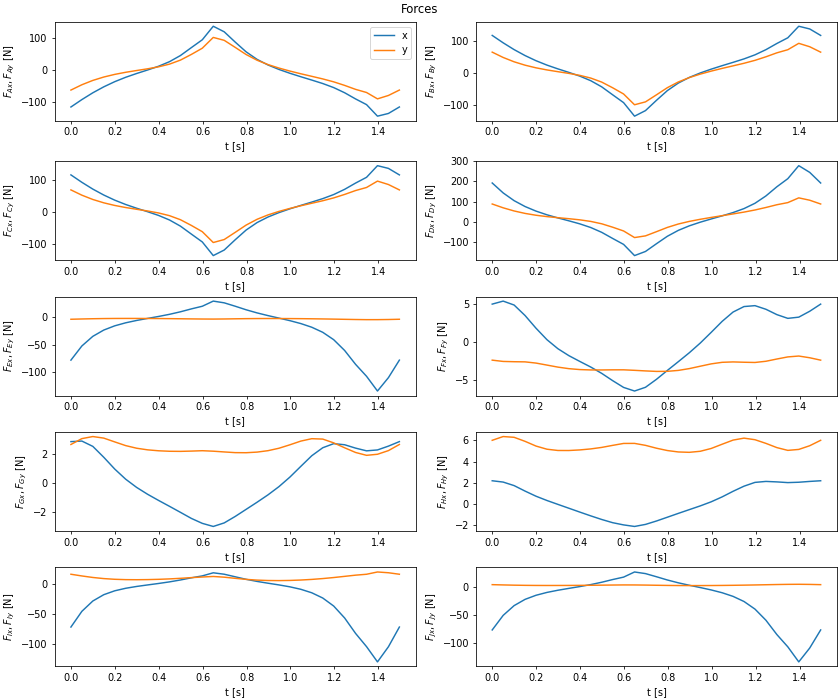

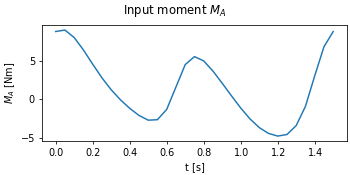

In [14]:
# plot forces and moments:
fig3, ax3 = plt.subplots(nrows=5, ncols=2, constrained_layout=True, figsize=(12, 10))
fig3.suptitle("Forces")

force_pairs = [
    ("A", F_A_x, F_A_y),
    ("B", F_B_x, F_B_y),
    ("C", F_C_x, F_C_y),
    ("D", F_D_x, F_D_y),
    ("E", F_E_x, F_E_y),
    ("F", F_F_x, F_F_y),
    ("G", F_G_x, F_G_y),
    ("H", F_H_x, F_H_y),
    ("I", F_I_x, F_I_y),
    ("J", F_J_x, F_J_y),
]

for axis, (label, force_x, force_y) in zip(ax3.flat, force_pairs):
    axis.plot(t, force_x, label="x")
    axis.plot(t, force_y, label="y")
    axis.set_ylabel(rf'$F_{{{label}x}}, F_{{{label}y}}$ [N]')
    axis.set_xlabel('t [s]')

ax3[0, 0].legend()
plt.show()

fig4, ax4 = plt.subplots(constrained_layout=True, figsize=(5, 2.5))
fig4.suptitle("Input moment $M_A$")
ax4.plot(t, M_A)
ax4.set_ylabel(r'$M_A$ [Nm]')
ax4.set_xlabel('t [s]')
plt.show()


<a id="sectie-14"></a>
## 14. Onbalanskrachten


-52.997017619929736


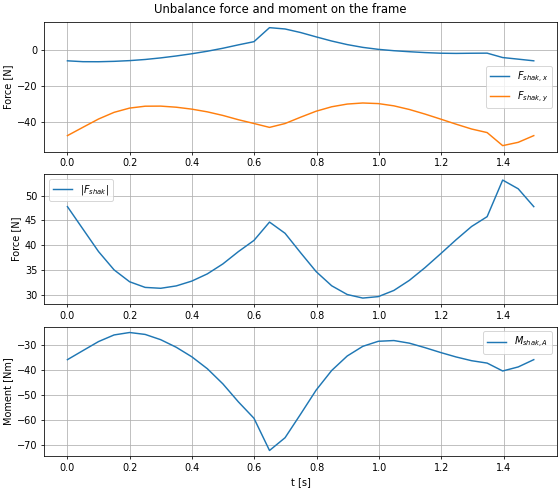

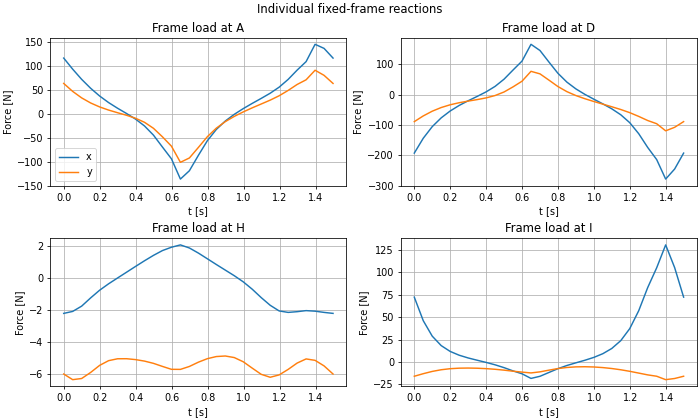

In [15]:
# Unbalance / shaking analysis:
# F_A, F_D, F_H and F_I are forces exerted by the fixed frame on the mechanism.
# The shaking force and moment on the fixed frame therefore have the opposite sign.
F_shak_x = -(F_A_x + F_D_x + F_H_x + F_I_x)
F_shak_y = -(F_A_y + F_D_y + F_H_y + F_I_y)
F_shak = np.sqrt(F_shak_x**2 + F_shak_y**2)

M_shak = -(
    grondA_x * F_A_y - grondA_y * F_A_x +
    grondD_x * F_D_y - grondD_y * F_D_x +
    grondH_x * F_H_y - grondH_y * F_H_x +
    grondI_x * F_I_y - grondI_y * F_I_x +
    M_A
)

fig_shak, ax_shak = plt.subplots(nrows=3, ncols=1, constrained_layout=True, figsize=(8, 7))
fig_shak.suptitle('Unbalance force and moment on the frame')

ax_shak[0].plot(t, F_shak_x, label=r'$F_{shak,x}$')
ax_shak[0].plot(t, F_shak_y, label=r'$F_{shak,y}$')
ax_shak[0].set_ylabel('Force [N]')
ax_shak[0].legend()
ax_shak[0].grid()

print(min(F_shak_y))
ax_shak[1].plot(t, F_shak, label=r'$|F_{shak}|$')
ax_shak[1].set_ylabel('Force [N]')
ax_shak[1].legend()
ax_shak[1].grid()

ax_shak[2].plot(t, M_shak, label=r'$M_{shak,A}$')
ax_shak[2].set_ylabel('Moment [Nm]')
ax_shak[2].set_xlabel('t [s]')
ax_shak[2].legend()
ax_shak[2].grid()
plt.show()

fixed_support_forces = [
    ('A', F_A_x, F_A_y),
    ('D', F_D_x, F_D_y),
    ('H', F_H_x, F_H_y),
    ('I', F_I_x, F_I_y),
]

fig_support, ax_support = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize=(10, 6))
fig_support.suptitle('Individual fixed-frame reactions')
for axis, (label, force_x, force_y) in zip(ax_support.flat, fixed_support_forces):
    axis.plot(t, -force_x, label='x')
    axis.plot(t, -force_y, label='y')
    axis.set_title(f'Frame load at {label}')
    axis.set_ylabel('Force [N]')
    axis.set_xlabel('t [s]')
    axis.grid()
ax_support[0, 0].legend()
plt.show()

**Besluit onbalans.** De totale verticale framekracht wordt vooral bepaald door het eigengewicht van het mechanisme. De dynamische inertiële onbalans blijft klein door de lage motorsnelheid. Het belangrijkste aandachtspunt is daarom niet de globale shaking force, maar de lokale framebelasting, vooral in steunpunt `D`, en het shaking moment op het frame.


<a id="sectie-15"></a>
## 15. Controle van de onbalanskrachten


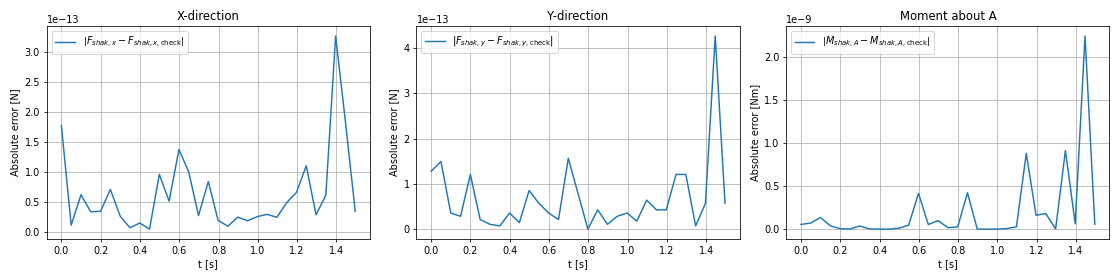

In [16]:
F_shak_x_check = -(
    m1 * acc_1x + m2 * acc_2x + m3 * acc_3x + m4 * acc_4x +
    m5 * acc_5x + m6 * acc_6x + m7 * acc_7x
) + F_wiper_left_x + F_wiper_right_x
F_shak_y_check = -(
    m1 * acc_1y + m2 * acc_2y + m3 * acc_3y + m4 * acc_4y +
    m5 * acc_5y + m6 * acc_6y + m7 * acc_7y
) - (m1 + m2 + m3 + m4 + m5 + m6 + m7) * g + F_wiper_left_y + F_wiper_right_y

(
    cog_1_x, cog_1_y, cog_2_x, cog_2_y, cog_3_x, cog_3_y,
    cog_4_x, cog_4_y, cog_5_x, cog_5_y, cog_6_x, cog_6_y,
    cog_7_x, cog_7_y
) = center_of_mass_positions(
    theta1, theta2, theta3, theta4, theta5, theta6, theta7,
    r1, rED, rDF,
    grondA_x, grondA_y, grondD_x, grondD_y, grondH_x, grondH_y, grondI_x, grondI_y,
    X1, X2, X3, X4, X5, X6, X7,
    Y1, Y2, Y3, Y4, Y5, Y6, Y7
)

# As in Les 3: dH/dt = sum(J*alpha + r_cg x m*a_cg), about fixed point A.
M_inertia_about_A = (
    J1 * ddtheta1 + m1 * (cog_1_x * acc_1y - cog_1_y * acc_1x) +
    J2 * ddtheta2 + m2 * (cog_2_x * acc_2y - cog_2_y * acc_2x) +
    J3 * ddtheta3 + m3 * (cog_3_x * acc_3y - cog_3_y * acc_3x) +
    J4 * ddtheta6 + m4 * (cog_4_x * acc_4y - cog_4_y * acc_4x) +
    J5 * ddtheta7 + m5 * (cog_5_x * acc_5y - cog_5_y * acc_5x) +
    J6 * ddtheta4 + m6 * (cog_6_x * acc_6y - cog_6_y * acc_6x) +
    J7 * ddtheta5 + m7 * (cog_7_x * acc_7y - cog_7_y * acc_7x)
)

M_gravity_about_A = -g * (
    m1 * cog_1_x + m2 * cog_2_x + m3 * cog_3_x + m4 * cog_4_x +
    m5 * cog_5_x + m6 * cog_6_x + m7 * cog_7_x
)
M_wiper_about_A = (
    cog_3_x * F_wiper_left_y - cog_3_y * F_wiper_left_x + M_wiper_left_cog +
    cog_5_x * F_wiper_right_y - cog_5_y * F_wiper_right_x + M_wiper_right_cog
)
M_hinge_friction_about_A = (
    M_hinge_1 + M_hinge_2 + M_hinge_3 + M_hinge_4 +
    M_hinge_5 + M_hinge_6 + M_hinge_7
)
M_shak_check = (
    -M_inertia_about_A + M_gravity_about_A +
    M_wiper_about_A + M_hinge_friction_about_A
)

fig, axs = plt.subplots(1, 3, figsize=(16, 4))

# --- X richting ---
axs[0].plot(t, abs(F_shak_x - F_shak_x_check),
            label=r'$\left| F_{shak,x} - F_{shak,x,\mathrm{check}} \right|$')
axs[0].set_xlabel('t [s]')
axs[0].set_ylabel('Absolute error [N]')
axs[0].set_title('X-direction')
axs[0].grid()
axs[0].legend()

# --- Y richting ---
axs[1].plot(t, abs(F_shak_y - F_shak_y_check),
            label=r'$\left| F_{shak,y} - F_{shak,y,\mathrm{check}} \right|$')
axs[1].set_xlabel('t [s]')
axs[1].set_ylabel('Absolute error [N]')
axs[1].set_title('Y-direction')
axs[1].grid()
axs[1].legend()

# --- Moment rond A ---
axs[2].plot(t, abs(M_shak - M_shak_check),
            label=r'$\left| M_{shak,A} - M_{shak,A,\mathrm{check}} \right|$')
axs[2].set_xlabel('t [s]')
axs[2].set_ylabel('Absolute error [Nm]')
axs[2].set_title('Moment about A')
axs[2].grid()
axs[2].legend()

plt.tight_layout()
plt.show()

<a id="sectie-16"></a>
## 16. Energiecontrole


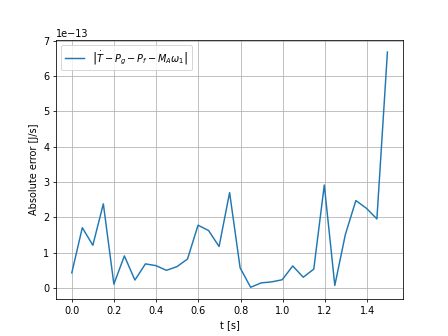

In [17]:
#Tijdsafgeleide van de energie berekenen dE/dt
P_kin = (
    m1 * (vel_1x * acc_1x + vel_1y * acc_1y) +
    m2 * (vel_2x * acc_2x + vel_2y * acc_2y) +
    m3 * (vel_3x * acc_3x + vel_3y * acc_3y) +
    m4 * (vel_4x * acc_4x + vel_4y * acc_4y) +
    m5 * (vel_5x * acc_5x + vel_5y * acc_5y) +
    m6 * (vel_6x * acc_6x + vel_6y * acc_6y) +
    m7 * (vel_7x * acc_7x + vel_7y * acc_7y) +
    J1 * dtheta1 * ddtheta1 +
    J2 * dtheta2 * ddtheta2 +
    J3 * dtheta3 * ddtheta3 +
    J4 * dtheta6 * ddtheta6 +
    J5 * dtheta7 * ddtheta7 +
    J6 * dtheta4 * ddtheta4 +
    J7 * dtheta5 * ddtheta5
)

P_gravity = -g * (
    m1 * vel_1y + m2 * vel_2y + m3 * vel_3y + m4 * vel_4y +
    m5 * vel_5y + m6 * vel_6y + m7 * vel_7y
)
P_inversedyn = M_A*dtheta1
P_balance = P_kin - P_gravity - P_wiper_friction - P_hinge_friction

# plt.figure(figsize=(12, 6))

# plt.subplot(121)
# plt.plot(t, P_kin, label=r'$\frac{dE}{dt}$')
# plt.xlabel('t [s]')
# plt.ylabel('Variation of total energy [J/s]')
# plt.legend()
# plt.grid()
# plt.xlim(t_begin-0.05, t_end+0.05)

# plt.subplot(122)
# plt.plot(t, P_inversedyn, label=r'$M_A . \omega_1$')
# plt.plot(t, P_balance, '--', label=r'$\dot{T} - P_g - P_{f,wiper} - P_{f,hinge}$')
# plt.xlabel('t [s]')
# plt.ylabel('Variation of total energy [J/s]')
# plt.legend()
# plt.grid()
# plt.xlim(t_begin-0.05, t_end+0.05)

# plt.tight_layout()
# plt.show()

plt.figure()
plt.plot(t, abs(P_inversedyn - P_balance), label=r'$\left| \dot{T} - P_g - P_f - M_A \omega_1 \right|$')
plt.xlabel('t [s]')
plt.ylabel(r'Absolute error [J/s]')
plt.grid()
plt.legend()
plt.show()


**Besluit energiecontrole.** De vermogensbalans vergelijkt het vermogen uit de inverse dynamica met de verandering van kinetische energie, zwaartekrachtvermogen en wrijvingsverliezen. De foutplot hoort dicht bij nul te blijven; dat bevestigt dat de krachten, momenten, zwaartekracht en wrijving consistent in het model zitten.


<a id="sectie-17"></a>
## 17. Motoranalyse


Motoranalyse
Piekmoment:             8.96 Nm
Continu/RMS-moment:     4.33 Nm
Piekvermogen:           37.6 W
Gemiddeld motorvermogen:10.2 W
 --> Alleen het positieve vermogen telt voor energieverbruik.

Met veiligheidsfactor
Veiligheidsfactor:      1.50
Motorpiekmoment >=      13.4 Nm
Continu moment >=       6.49 Nm
Piekvermogen >=         56.4 W


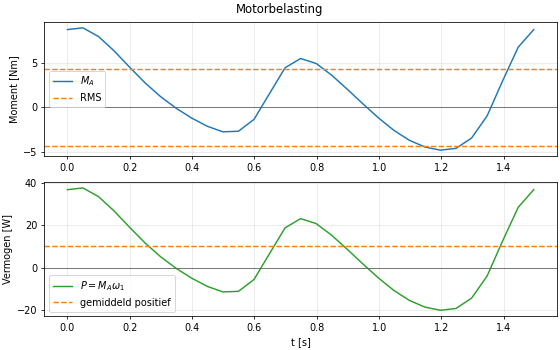

In [18]:
# Motor sizing: keep only the quantities that are needed for choosing a motor.
P_motor = M_A * dtheta1                  # signed mechanical power at the output shaft [W]
P_motoring = np.maximum(P_motor, 0)      # power that must be delivered by the motor [W]
P_braking = np.minimum(P_motor, 0)       # negative power: mechanism drives the motor back [W]

# Peak values size the short overload capability.
# RMS values are useful for continuous/thermal loading.
M_motor_peak = np.max(np.abs(M_A))
M_motor_rms = np.sqrt(cycle_average(M_A**2))
P_motor_peak = np.max(P_motoring)
P_motor_rms = np.sqrt(cycle_average(P_motoring**2))
P_motor_average = cycle_average(P_motor)
P_motor_average_motoring = cycle_average(P_motoring)
P_motor_peak_regen = -np.min(P_braking)

service_factor = 1.5
M_motor_peak_selected = service_factor * M_motor_peak
M_motor_continuous_selected = service_factor * M_motor_rms
P_motor_peak_selected = service_factor * P_motor_peak
P_motor_continuous_selected = service_factor * P_motor_rms

print('Motoranalyse')
print(f'Piekmoment:             {M_motor_peak:.3g} Nm')
print(f'Continu/RMS-moment:     {M_motor_rms:.3g} Nm')
print(f'Piekvermogen:           {P_motor_peak:.3g} W')
print(f'Gemiddeld motorvermogen:{P_motor_average_motoring:.3g} W')
print(' --> Alleen het positieve vermogen telt voor energieverbruik.')
print()
print('Met veiligheidsfactor')
print(f'Veiligheidsfactor:      {service_factor:.2f}')
print(f'Motorpiekmoment >=      {M_motor_peak_selected:.3g} Nm')
print(f'Continu moment >=       {M_motor_continuous_selected:.3g} Nm')
print(f'Piekvermogen >=         {P_motor_peak_selected:.3g} W')

fig_motor, ax_motor = plt.subplots(nrows=2, ncols=1, constrained_layout=True, figsize=(8, 5))
fig_motor.suptitle('Motorbelasting')

ax_motor[0].plot(t, M_A, color='tab:blue', label=r'$M_A$')
ax_motor[0].axhline(M_motor_rms, color='tab:orange', linestyle='--', label='RMS')
ax_motor[0].axhline(-M_motor_rms, color='tab:orange', linestyle='--')
ax_motor[0].axhline(0, color='0.35', linewidth=0.8)
ax_motor[0].set_ylabel('Moment [Nm]')
ax_motor[0].grid(True, alpha=0.3)
ax_motor[0].legend()

ax_motor[1].plot(t, P_motor, color='tab:green', label=r'$P=M_A\omega_1$')
ax_motor[1].axhline(P_motor_average_motoring, color='tab:orange', linestyle='--',
                    label='gemiddeld positief')
ax_motor[1].axhline(0, color='0.35', linewidth=0.8)
ax_motor[1].set_xlabel('t [s]')
ax_motor[1].set_ylabel('Vermogen [W]')
ax_motor[1].grid(True, alpha=0.3)
ax_motor[1].legend()
plt.show()


**Besluit motoranalyse.** Voor de motorkeuze zijn vooral drie waarden nodig: het piekmoment voor korte zware belasting, het RMS-moment voor de continue thermische belasting en het positieve motorvermogen voor het energieverbruik. Het vermogen kan tijdelijk negatief zijn; dan drijft het mechanisme de motor terug aan. Voor de gekozen motor telt daarom vooral dat het uitgangspiekmoment met veiligheidsfactor haalbaar blijft.


<a id="sectie-18"></a>
## 18. Motorkeuze en gebruikskost

Met `omega = 4.2 rad/s` draait de uitgangsas ongeveer **40 rpm**. Dat is een realistische normale wissnelheid voor een ruitenwisser. Door de hogere snelheid zijn de inertiekrachten groter dan bij de eerdere trage simulatie, waardoor het berekende piekmoment met veiligheidsfactor ongeveer **13 Nm** wordt. Een 10 Nm-motorunit is daardoor te krap.

Daarom wordt hier een **heavy-duty automotive 12 V DC-ruitenwissermotor met wormwielreductie** gekozen met een uitgangskoppel van ongeveer **15 Nm** en een uitgangstoerental van **40-60 rpm**. De wormwielreductie verlaagt het toerental van de elektromotor en verhoogt het beschikbare uitgangskoppel aan de wisseras.

Voor de kost wordt daarom onderscheid gemaakt tussen een catalogusprijs en een OEM/massaproductieprijs. Een losse aftermarket- of universele heavy-duty wissermotor kost typisch tientallen tot meer dan honderd euro, terwijl een autofabrikant bij grote aantallen lager inkoopt. In deze berekening wordt daarom een realistische **OEM-richtprijs van 35 euro per motorunit** aangenomen. Dit is een ontwerpaanname, geen publieke offerteprijs.

Voor de energiekost wordt gerekend met het gemiddelde positieve mechanische motorvermogen en een aangenomen aandrijfrendement van 65%. De Belgische huishoudelijke elektriciteitsprijs wordt hier afgerond op **0,35 euro/kWh**, gebaseerd op Eurostat-waarden voor Belgische huishoudens in 2025. Dit is een all-in benadering met belastingen en nettarieven; je eigen contract kan hiervan afwijken.

Bronnen ter referentie: universele/aftermarket 12 V-wissermotoren tonen dat catalogusprijzen sterk verschillen per toepassing en aankoopkanaal, bijvoorbeeld https://piarulliagrigarden.eu/product/12v-wiper-motor-with-short-rod/ en https://www.svb24.com/en/roca-w12-heavy-duty-wiper-motor.html . Elektriciteitsprijs: Eurostat, household electricity prices H2 2025: https://ec.europa.eu/eurostat/web/products-eurostat-news/w/ddn-20260505-1


In [19]:
# Concrete motor choice and energy-cost estimate for an automotive/OEM context:
selected_motor_name = 'Heavy-duty automotive 12 V DC wiper motor with worm gearbox'
selected_motor_nominal_torque = 15.0      # [Nm], output shaft torque
selected_motor_speed_range_rpm = (40, 60) # [rpm], typical output speed range
selected_motor_voltage = 12               # [V]
selected_motor_oem_price = 35.00          # [euro], assumed OEM mass-production cost
selected_motor_aftermarket_price_range = (60, 150)  # [euro], typical replacement-part range

motor_efficiency = 0.65                # [-], assumed motor + gearbox + driver efficiency
electricity_price = 0.35               # [euro/kWh], Belgian household all-in estimate

cycle_time = t[-1] - t[0]
cycles_per_hour = 3600 / cycle_time

P_electrical_average = P_motor_average_motoring / motor_efficiency
E_electrical_per_cycle_kWh = P_electrical_average * cycle_time / (1000 * 3600)
E_electrical_per_hour_kWh = P_electrical_average / 1000
energy_cost_per_cycle = E_electrical_per_cycle_kWh * electricity_price
energy_cost_per_hour = E_electrical_per_hour_kWh * electricity_price

print('Selected motor')
print(f'Motor:                         {selected_motor_name}')
print(f'Nominal torque:                {selected_motor_nominal_torque:.4g} Nm')
print(f'Speed range:                   {selected_motor_speed_range_rpm[0]}-{selected_motor_speed_range_rpm[1]} rpm')
print(f'Voltage:                       {selected_motor_voltage:.4g} V')
print(f'Assumed OEM price:             {selected_motor_oem_price:.2f} euro per unit')
print(f'Aftermarket reference range:   {selected_motor_aftermarket_price_range[0]}-{selected_motor_aftermarket_price_range[1]} euro')
print()
print('Check against calculated requirement')
print(f'Required peak torque with SF:  {M_motor_peak_selected:.4g} Nm')
print(f'Required continuous torque:    {M_motor_continuous_selected:.4g} Nm')
print(f'Torque margin vs peak+SF:      {selected_motor_nominal_torque / M_motor_peak_selected:.3g} x')
print()
print('Energy-use estimate')
print(f'Assumed efficiency:            {motor_efficiency:.0%}')
print(f'Electricity price:             {electricity_price:.2f} euro/kWh')
print(f'Average electrical power:      {P_electrical_average:.4g} W')
print(f'Cycle time:                    {cycle_time:.4g} s')
print(f'Cycles per hour:               {cycles_per_hour:.4g}')
print(f'Electrical energy per cycle:   {E_electrical_per_cycle_kWh:.4g} kWh')
print(f'Energy cost per cycle:         {energy_cost_per_cycle:.4g} euro')
print(f'Electrical energy per hour:    {E_electrical_per_hour_kWh:.4g} kWh')
print(f'Energy cost per hour:          {energy_cost_per_hour:.4g} euro/h')


Selected motor
Motor:                         Heavy-duty automotive 12 V DC wiper motor with worm gearbox
Nominal torque:                15 Nm
Speed range:                   40-60 rpm
Voltage:                       12 V
Assumed OEM price:             35.00 euro per unit
Aftermarket reference range:   60-150 euro

Check against calculated requirement
Required peak torque with SF:  13.43 Nm
Required continuous torque:    6.49 Nm
Torque margin vs peak+SF:      1.12 x

Energy-use estimate
Assumed efficiency:            65%
Electricity price:             0.35 euro/kWh
Average electrical power:      15.72 W
Cycle time:                    1.496 s
Cycles per hour:               2406
Electrical energy per cycle:   6.533e-06 kWh
Energy cost per cycle:         2.287e-06 euro
Electrical energy per hour:    0.01572 kWh
Energy cost per hour:          0.005502 euro/h


<a id="sectie-19"></a>
## 19. Vliegwielanalyse


Flywheel design estimate
Average torque over cycle:      1.24 Nm
Maximum work surplus A_max:     8.031 J
Allowed fluctuation K:          0.05
Required flywheel inertia:      9.105 kg m^2

Steel disc estimate
Assumed disc radius:            0.1 m
Required disc thickness:        7.384 m
Disc mass:                      1821 kg

Steel rim estimate on slow wiper shaft
Assumed mean rim radius:        0.1 m
Approximate rim mass:           910.5 kg

Equivalent flywheel on motor side
Assumed gear ratio:             50
Required motor-side inertia:    0.003642 kg m^2
Approximate motor-side rim mass:0.3642 kg


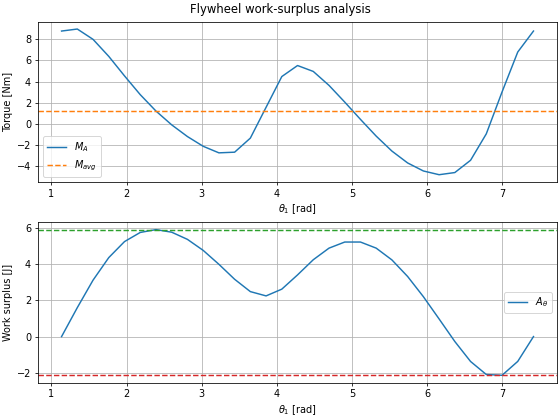

In [20]:
# Flywheel design based on the work surplus from Les 4:
# A_theta = integral((M_A - M_average) dtheta)
# A_max = max(A_theta) - min(A_theta)
# I_flywheel = A_max / (K * omega_average**2)

theta_driver = theta1
torque_average = np.trapezoid(M_A, theta_driver) / (theta_driver[-1] - theta_driver[0])
torque_fluctuation = M_A - torque_average

dtheta_driver = np.diff(theta_driver)
work_increment = 0.5 * (torque_fluctuation[1:] + torque_fluctuation[:-1]) * dtheta_driver
A_theta = np.concatenate(([0], np.cumsum(work_increment)))
A_max = np.max(A_theta) - np.min(A_theta)

K_allowed = 0.05  # total speed fluctuation: (omega_max - omega_min) / omega_average
omega_average = cycle_average(dtheta1)
I_flywheel_required = A_max / (K_allowed * omega_average**2)

# Simple steel disc estimate: I = pi * R**4 * thickness * rho / 2
rho_steel = 7850  # kg/m^3
R_disc = 0.10     # m, assumed packaging radius
disc_thickness = 2 * I_flywheel_required / (np.pi * R_disc**4 * rho_steel)
disc_mass = np.pi * R_disc**2 * disc_thickness * rho_steel

# Rim estimate on the slow output shaft: I ~= m * R_m**2
R_rim_mean = 0.10
rim_mass = I_flywheel_required / R_rim_mean**2

# If a flywheel is mounted on the motor side of a gearbox, the required physical inertia
# is reduced by the square of the reduction ratio.
gear_ratio = 50  # omega_motor / omega_wiper
I_flywheel_motor_side = I_flywheel_required / gear_ratio**2
rim_mass_motor_side = I_flywheel_motor_side / R_rim_mean**2

print('Flywheel design estimate')
print(f'Average torque over cycle:      {torque_average:.4g} Nm')
print(f'Maximum work surplus A_max:     {A_max:.4g} J')
print(f'Allowed fluctuation K:          {K_allowed:.4g}')
print(f'Required flywheel inertia:      {I_flywheel_required:.4g} kg m^2')
print()
print('Steel disc estimate')
print(f'Assumed disc radius:            {R_disc:.4g} m')
print(f'Required disc thickness:        {disc_thickness:.4g} m')
print(f'Disc mass:                      {disc_mass:.4g} kg')
print()
print('Steel rim estimate on slow wiper shaft')
print(f'Assumed mean rim radius:        {R_rim_mean:.4g} m')
print(f'Approximate rim mass:           {rim_mass:.4g} kg')
print()
print('Equivalent flywheel on motor side')
print(f'Assumed gear ratio:             {gear_ratio:.4g}')
print(f'Required motor-side inertia:    {I_flywheel_motor_side:.4g} kg m^2')
print(f'Approximate motor-side rim mass:{rim_mass_motor_side:.4g} kg')

fig_fw, ax_fw = plt.subplots(nrows=2, ncols=1, constrained_layout=True, figsize=(8, 6))
fig_fw.suptitle('Flywheel work-surplus analysis')
ax_fw[0].plot(theta_driver, M_A, label=r'$M_A$')
ax_fw[0].axhline(torque_average, color='tab:orange', linestyle='--', label=r'$M_{avg}$')
ax_fw[0].set_xlabel(r'$\theta_1$ [rad]')
ax_fw[0].set_ylabel('Torque [Nm]')
ax_fw[0].grid()
ax_fw[0].legend()

ax_fw[1].plot(theta_driver, A_theta, label=r'$A_\theta$')
ax_fw[1].axhline(np.max(A_theta), color='tab:green', linestyle='--')
ax_fw[1].axhline(np.min(A_theta), color='tab:red', linestyle='--')
ax_fw[1].set_xlabel(r'$\theta_1$ [rad]')
ax_fw[1].set_ylabel('Work surplus [J]')
ax_fw[1].grid()
ax_fw[1].legend()
plt.show()


<a id="sectie-20"></a>
## 20. Besluit over het vliegwiel

Voor dit mechanisme is een vliegwiel op de trage ruitenwisser-as niet nuttig. De ruitenwisser draait traag, waardoor de energieopslag van een vliegwiel klein is voor een gegeven massa: $E = \frac{1}{2} I \omega^2$. Bij een kleine straal van bijvoorbeeld 6 cm leidt zelfs een beperkte gewenste inertie dus tot een onrealistische massa. Een vliegwiel aan de snelle motorzijde van een reductiekast zou veel kleiner zijn, omdat de equivalente inertie met het kwadraat van de overbrengingsverhouding wordt geschaald. Toch blijft voor een elektrische ruitenwisser motorselectie op piekkoppel, RMS-koppel, piekvermogen en thermische marge logischer dan het toevoegen van een vliegwiel.

<a id="sectie-21"></a>
## 21. Examen-checklist



| verwacht onderdeel | waar staat het? | snel aanpasbare parameters |
|---|---|---|
| kinematica mechanisme | secties 2-10 | `r1...r7`, `grondA/D/H/I`, `omega`, `theta1_0`, beginwaarden van `fsolve` |
| inverse dynamica met zwaartekracht en wrijving | secties 11-13 | `m1...m7`, `g`, `mu_wiper_glass`, `normal_force_wiper`, `c_hinge`, `M_c_hinge` |
| onbalans-analyse | secties 14-15 | massa's, massacentra `X1...X7`, motorsnelheid `omega` |
| krachten en vermogens | secties 13, 16 en 17 | wrijving, massa's, snelheid en geometrie |
| motorselectie en kost | sectie 18 | `selected_motor_*`, `motor_efficiency`, `electricity_price`, gebruiksduur |
| vliegwielontwerp | secties 19-20 | `K_allowed`, `R_disc`, `R_rim_mean`, `rho_steel`, `gear_ratio`, `omega` |
| ontwerp van een nok en nokveer | aparte notebook `Algoritme-nok-ontwerp-2.ipynb` | bewegingsspecificatie, `motionlaw`, `R0`, `follower_radius`, `exc`, veervoorspanning |


Aanpak tijdens het mondeling: wijzig eerst de gevraagde parameter in de relevante invoercel, kies daarna **Run All Below** vanaf die sectie. Bij geometriewijzigingen start je best vanaf sectie 2, omdat alle sluitingsvergelijkingen, snelheden en dynamica daarvan afhangen.


<a id="sectie-22"></a>
## 22. Mondelinge vragen: korte kapstok

1. **Industriele toepassing.** Ruitenwissers zetten een continue motordraaiing om in een oscillerende wisbeweging. Voor een andere ruit of toepassing pas je vooral slaghoek, armlengtes, grondpunten en motorpositie aan; voor timing verander je `omega` of vervang je de constante aandrijving door een opgelegd traject.

2. **Optimalisatie.** Precisie vraagt hoge transmissiehoek, weinig speling, stijve armen en lagere versnellingen. Energieverbruik vraagt lagere massa, lagere wrijving, gunstige balans en een traject met minder piekversnelling. Krachtgeneratie vraagt korte momentarmen aan de belaste zijde, grotere motorreductie en vermijden van slechte transmissiehoeken.

3. **Vliegwiel.** Trade-off tussen snelheidsrimpel `K`, massa, diameter en plaatsing. Op de trage wisseras wordt het vliegwiel zwaar; aan de snelle motorzijde is het veel efficiënter door de hogere hoeksnelheid.

4. **Bewegingstraject.** Een constante `omega` is eenvoudig en past bij een DC-motor met reductie. Een aangepast traject kan piekvermogen en schokken beperken, maar vraagt sturing en kan de synchronisatie tussen beide wisserarmen complexer maken.

5. **Frequentie-inhoud.** Gebruik de frequentie-inhoud van koppel, onbalanskracht of beweging om excitatie rond eigenfrequenties te vermijden en om te beslissen of een gladdere bewegingswet, lagere snelheid, demping of een vliegwiel nuttig is.

6. **Dode punten / singulariteiten.** Controleer dit via sluitingsvergelijkingen, transmissiehoeken en numerieke convergentie. Een singulariteit is erg als de motor daar geen controle of momentoverdracht meer heeft; voor een ruitenwisser wil je die buiten het werkgebied houden.

7. **Onbalans.** Secties 13-14 geven de shaking force en shaking moment op het frame. Grote onbalans veroorzaakt trillingen, lagerbelasting en geluid; verlagen kan met lichtere armen, tegenmassa's, symmetrie of lagere snelheid.

8. **Inertie, wrijving en stijfheid.** Inertie schaalt sterk met `omega^2` en bepaalt piekkoppel bij snelle bewegingen. Wrijving geeft blijvend vermogensverlies en warmte. Stijfheid zit niet expliciet in dit stijve-stangenmodel, maar bepaalt in werkelijkheid positieafwijking en trillingen.

9. **Meerdere mechanismen parallel.** Koppels en vermogens tellen ongeveer op. Door fases te verschuiven kunnen onbalans en piekvermogen deels uitmiddelen; synchrone aandrijving maakt de motor en as zwaarder belast.

10. **Parameter wijzigen.** Kies een parameter met voorspelbare richting: hogere `omega` verhoogt inertiekrachten en piekvermogen; hogere `mu_wiper_glass` verhoogt wrijvingsvermogen; grotere massa verhoogt zwaartekracht- en inertietermen. Pas de parameter aan en herbereken de bijhorende secties.

**Vaste bijvraag motor en energie.** De gekozen motor staat in sectie 18: heavy-duty automotive 12 V ruitenwissermotor met wormwielreductie, ongeveer 15 Nm uitgangskoppel, richtprijs ongeveer 35 euro OEM en 60-150 euro aftermarket. De energiekost volgt uit het gemiddelde positieve mechanische vermogen, het rendement en `electricity_price`.
